In [36]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("/home/cmp/Documents/Github/Stoner-SCF/out/find_gs.csv")
# Filtered Unconverged
df = df[df['Energy'] != 0]
df.head()

,Seed,Energy,Threshold,Rho2Trace
0,0,30.369963,1.000000e-07,8.256062
1,1,30.369963,1.000000e-07,8.256062
2,2,30.369963,1.000000e-07,8.256062
3,3,30.369963,1.000000e-07,8.256062
4,4,30.369963,1.000000e-04,8.256062


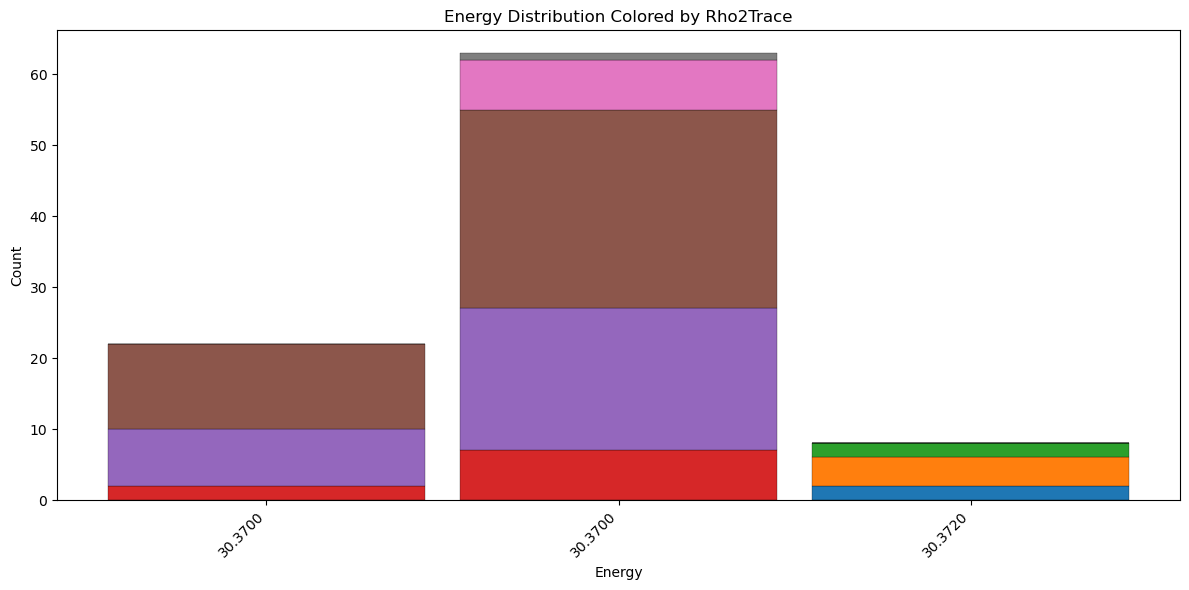

In [38]:
# --- Round to collapse floating-point noise into true groups ---
# Adjust decimal precision based on how close your "same" values actually are
df["Energy_grp"] = df["Energy"]
df["Rho2Trace_grp"] = df["Rho2Trace"].round(7)

# --- Build a count table: rows = energy groups, cols = rho2trace groups ---
counts = df.groupby(["Energy_grp", "Rho2Trace_grp"]).size().unstack(fill_value=0)
counts = counts.sort_index()  # sort by energy

# --- Assign a consistent color per Rho2Trace value across the whole plot ---
rho_values = counts.columns
colors = cm.viridis(np.linspace(0, 1, len(rho_values)))

# --- Plot stacked bars, one bar per unique energy ---
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(counts))
x = np.arange(len(counts))

for color, rho in zip(colors, rho_values):
    heights = counts[rho].values
    ax.bar(x, heights, bottom=bottom, width=0.9, edgecolor="black", linewidth=0.2)
    bottom += heights

ax.set_xlabel("Energy")
ax.set_ylabel("Count")
ax.set_title("Energy Distribution Colored by Rho2Trace")

# Thin out x-tick labels since there may be many unique energies
step = max(1, len(counts) // 20)
ax.set_xticks(x[::step])
ax.set_xticklabels([f"{e:.4f}" for e in counts.index[::step]], rotation=45, ha="right")

plt.tight_layout()
plt.savefig("energy_histogram.png", dpi=150)
plt.show()

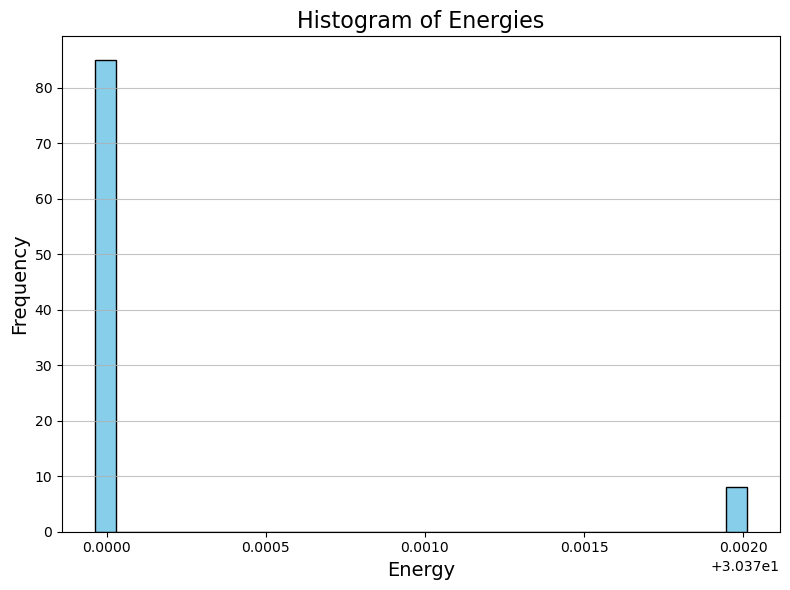

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df['Energy'], bins=30, color='skyblue', edgecolor='black')

ax.set_title('Histogram of Energies', fontsize=16)
ax.set_xlabel('Energy', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

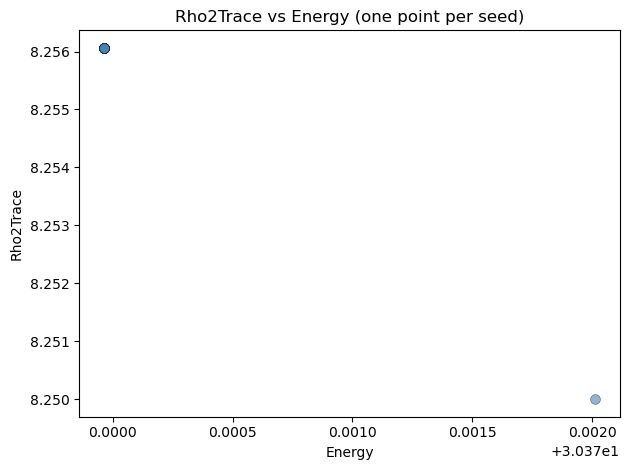

In [40]:
# --- Scatter: Energy vs Rho2Trace, one point per seed ---
fig, ax = plt.subplots()

ax.scatter(
    df["Energy"],
    df["Rho2Trace"],
    s=50,
    alpha=0.1,
    edgecolor="black",
    linewidth=0.3,
    color="steelblue",
)

ax.set_xlabel("Energy")
ax.set_ylabel("Rho2Trace")
ax.set_title("Rho2Trace vs Energy (one point per seed)")

plt.tight_layout()
plt.savefig("energy_vs_rho2trace_scatter.png", dpi=150)
plt.show()